In [ ]:
from tsgen import SyntheticSeries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose, STL , MSTL
from fft import fft_spectrum, plot_fft
import plotly.graph_objects as go
from plotly.subplots import make_subplots

c:\Users\paulinkenbrandt\Documents\GitHub\anomolous_ts\src\anomolous_ts\tsgen.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index = pd.date_range(start=start, periods=periods, freq=freq)


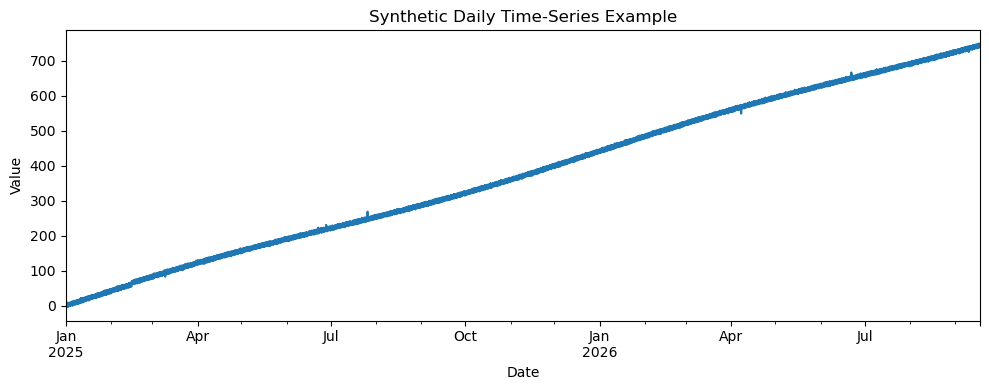

In [40]:
# ------------------------------------------------------------------
# Generate an example synthetic series
# ------------------------------------------------------------------
series = (
    SyntheticSeries("2025-01-01", periods=15000, freq="H", seed=42)
    .add_trend(slope=0.05)                 # gentle upward trend
    .add_seasonality(period=24, amplitude=5)  # monthly-ish cycle
    .add_seasonality(period=365.25*24, amplitude=10)   # weekly cycle
    .add_white_noise(std=1.0)              # Gaussian white noise
    .add_spikes(n_spikes=5, magnitude=15)  # occasional outliers
    .add_block_spikes(width=5, n_blocks=2, magnitude=8)
    .add_step_offset("2025-02-15", offset=4)   # permanent upward shift
    .to_series(name="synthetic")
)


# Plot the full series
fig, ax = plt.subplots(figsize=(10, 4))
series.plot(ax=ax)
ax.set_title("Synthetic Daily Time-Series Example")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

   amplitude     frequency                     period
0   8.400433  3.703704e-08          312 days 12:00:00
1   5.009323  1.157407e-05            1 days 00:00:00
2   0.160013  2.962963e-07           39 days 01:30:00
3   0.145738  2.407407e-07 48 days 01:50:46.153846154


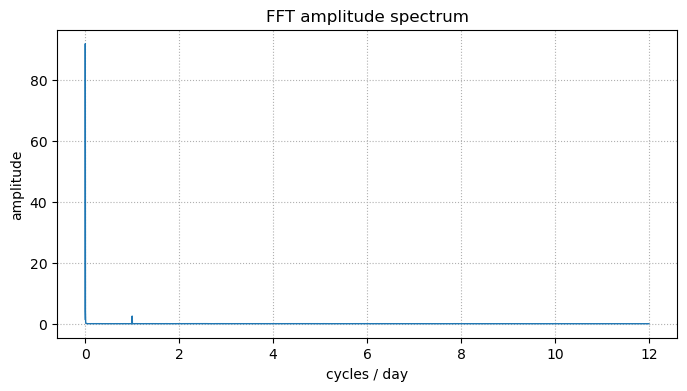

In [41]:


# ts is a Series with a DateTimeIndex
seasonal_peaks = fft_spectrum(series, 
                              detrend="linear", 
                              top_n=4, 
                              min_period = pd.Timedelta(days=400))

print(seasonal_peaks)

plot_fft(series, window="hanning", x_unit="per_day")
plt.show()


In [43]:
peaks

array([312,   1])

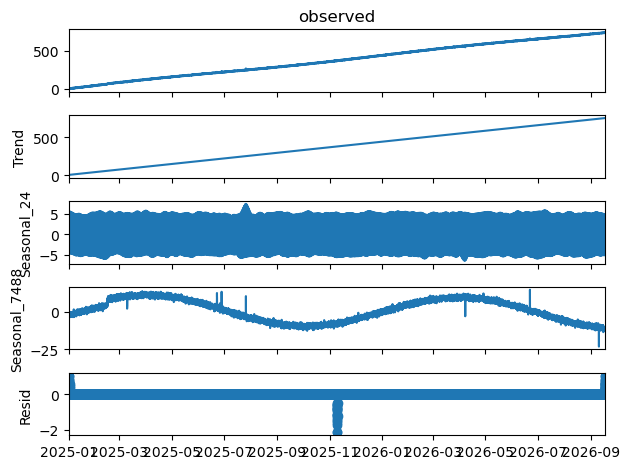

In [44]:
#period = 100
peaks = seasonal_peaks['period'][:2].apply(lambda x: x.days).values*24

res = MSTL(series,periods=peaks).fit()
res.plot()
plt.tight_layout()
plt.show()
# Plot the results
#plot_components(result_stl)

In [ ]:
# ---------------------------------------------------------------------------
# Detect anomalies with Isolation Forest
# ---------------------------------------------------------------------------
anomalies, scores = detect_isolation_forest(
    ts, contamination=0.015, lags=(1, 7, 14, 30), return_scores=True, random_state=0
)

# ---------------------------------------------------------------------------
# Plot the time series with detected anomalies highlighted
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ts.plot(ax=ax, label="Time series")
ts[anomalies].plot(ax=ax, marker="o", ls="", label="Detected anomalies")
ax.set_title("Isolation Forest anomaly detection")
ax.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Display anomalies with their scores in an interactive table
# ---------------------------------------------------------------------------
df_anom = pd.DataFrame({"value": ts[anomalies], "score": scores[anomalies]})
ace_tools.display_dataframe_to_user("Detected anomalies", df_anom)

2025-01-01     2.710328
2025-01-02     2.764682
2025-01-03     2.819031
2025-01-04     2.873377
2025-01-05     2.927718
                ...    
2029-02-04    79.011550
2029-02-05    79.063245
2029-02-06    79.114941
2029-02-07    79.166639
2029-02-08    79.218337
Freq: D, Name: trend, Length: 1500, dtype: float64